##### Objective
Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

#### Part A - Data Loading and Preprocessing with Scikit-learn

#### Task 1 - Load and Understand the Dataset

● Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

● Check the class distribution of is_canceled and use it as the target y.

● Create X from the remaining usable features. Identify numerical and categorical columns.

In [34]:
# Import the pandas library.
# Pandas is mainly used for working with datasets in the form of tables.
import pandas as pd

# Read the hotel_bookings.csv file and store it in a DataFrame called df.
# A DataFrame is a table-like structure containing rows and columns.
df = pd.read_csv("hotel_bookings.csv")

# Display the first 5 rows of the dataset.
# head() helps us quickly see what the data looks like.
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [35]:
# shape gives us the dimensions of the dataset.
# It returns two values:
#   - First value = number of rows
#   - Second value = number of columns
#
# For this dataset:
# 119390 rows and 32 columns
df.shape

(119390, 32)

In [36]:
# info() gives a summary of the DataFrame.
# It shows:
#   - Column names
#   - Number of non-null values in each column
#   - Data type of each column
#   - Total number of rows
#
# This is useful for understanding the structure of the dataset
# and identifying columns that may contain missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [37]:
# describe() gives statistical information about the numerical columns.
# It shows values such as:
#   - count  -> number of non-missing values
#   - mean   -> average value
#   - std    -> standard deviation
#   - min    -> minimum value
#   - 25%    -> first quartile
#   - 50%    -> median
#   - 75%    -> third quartile
#   - max    -> maximum value
#
# This helps us understand the numerical features in the dataset.
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [38]:
# dtypes shows the data type of every column in the dataset.
#
# Common data types we will see here are:
#   int64   -> integer/numerical values
#   float64 -> decimal/numerical values
#   object  -> usually text/categorical values
#
# We will use these data types later to identify
# numerical and categorical columns.
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [39]:
# is_canceled is the target variable that we want the machine
# learning model to predict later.
#
# The values are:
#   0 -> booking was not canceled
#   1 -> booking was canceled
#
# value_counts() counts how many times each class appears.
# This allows us to see the distribution of the target classes.
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [40]:
# Create y as the target variable.
#
# The target variable is the value that we want our machine
# learning model to predict.
#
# Here, is_canceled is the target, so y contains the
# cancellation status of every booking.
y = df["is_canceled"]

# Display the first 5 values of the target variable.
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

In [41]:
# Create X as the input features.
#
# We remove "is_canceled" from the dataset because it is our
# target variable and should not be included among the input features.
#
# axis=1 means that we are removing a COLUMN.
# inplace is not used here, so the original df remains unchanged.
X = df.drop("is_canceled", axis=1)

# Display the first 5 rows of the input features.
X.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [42]:
# Select all columns whose data type is numerical.
#
# int64 and float64 are numerical data types in this dataset.
# These columns contain values that can be represented as numbers.
#
# The result is stored in numerical_cols as a list of column names.
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Display the names of the numerical columns.
numerical_cols

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [43]:
# Select all columns whose data type is "object".
#
# Object columns in this dataset mainly contain text values,
# such as hotel type, month, meal type, country, etc.
# These are treated as categorical features.
#
# The result is stored in categorical_cols as a list of column names.
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Display the names of the categorical columns.
categorical_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

In [44]:
# Check the shape of X to see how many rows and usable features
# we have after removing the target column.
print("Shape of X:", X.shape)

# Check the shape of y to see how many target values we have.
print("Shape of y:", y.shape)

# Display the numerical feature column names.
print("\nNumerical columns:")
print(numerical_cols)

# Display the categorical feature column names.
print("\nCategorical columns:")
print(categorical_cols)

Shape of X: (119390, 31)
Shape of y: (119390,)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


#### Task 2 - Missing Values, Leakage, and Outliers

● Find the missing-value count and percentage for every column.

● Identify columns with very high missingness. Drop them only if justified and state the reason.

● Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

● Check selected numerical features for outliers using boxplots and/or the IQR method.

● Remove only clear/extreme outliers and report how many rows were removed.

In [45]:
# isnull() checks every cell in the dataset.
# If a cell contains a missing value, it returns True.
#
# sum() then counts the True values column-wise.
# Therefore, this gives us the total number of missing values
# present in every column.
missing_count = df.isnull().sum()

# Display the missing-value count for every column.
missing_count

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [46]:
# Calculate the percentage of missing values in every column.
#
# df.isnull().sum() gives the number of missing values.
# len(df) gives the total number of rows.
#
# We divide the missing count by the total number of rows
# and multiply by 100 to get the percentage.
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display the missing-value percentage for every column.
missing_percentage

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [47]:
# Create a table containing both:
#   1. Number of missing values
#   2. Percentage of missing values
#
# This makes it easier to examine the missing values
# for every column together.
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Display the missing-value summary.
missing_summary

,Missing Count,Missing Percentage
hotel,0,0.000000
is_canceled,0,0.000000
lead_time,0,0.000000
arrival_date_year,0,0.000000
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
arrival_date_day_of_month,0,0.000000
stays_in_weekend_nights,0,0.000000
stays_in_week_nights,0,0.000000
adults,0,0.000000


In [48]:
# We consider columns with more than 50% missing values
# as having very high missingness.
#
# The condition below checks which columns have a
# missing percentage greater than 50.
high_missing_cols = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

# Display the columns having very high missingness.
high_missing_cols

,Missing Count,Missing Percentage
company,112593,94.306893


In [49]:
# The "company" column has a very high percentage of missing values.
#
# Since more than half of its values are missing, keeping this
# column would provide limited useful information and would require
# extensive missing-value handling.
#
# Therefore, we remove it from X.
X = X.drop("company", axis=1)

# Display the new shape of X after removing the column.
X.shape

(119390, 30)

In [50]:
# reservation_status directly tells us what happened to the booking.
# For example, it can contain information such as:
#   - Canceled
#   - Check-Out
#   - No-Show
#
# This information is directly related to the final booking outcome.
#
# reservation_status_date contains the date associated with that
# final reservation status and can also reveal information about
# the final outcome.
#
# If these columns are given to a machine learning model,
# the model could learn information that would not be available
# when making a genuine prediction.
#
# Therefore, both columns are removed to prevent data leakage.
X = X.drop(
    ["reservation_status", "reservation_status_date"],
    axis=1
)

# Display the shape of X after removing the leakage columns.
X.shape

(119390, 28)

In [51]:
# X has been changed in the previous cells because:
#   1. "company" was removed because it has very high missingness.
#   2. "reservation_status" was removed because it causes data leakage.
#   3. "reservation_status_date" was removed because it causes data leakage.
#
# Therefore, we need to identify the numerical and categorical columns
# again using the UPDATED X.
#
# This is important because the old categorical_cols list from Task 1
# still contains the columns that we removed.

# Identify the numerical columns currently present in X.
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify the categorical columns currently present in X.
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display the updated numerical columns.
print("Numerical columns:")
print(numerical_cols)

# Display the updated categorical columns.
print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [52]:
# IQR stands for Interquartile Range.
#
# Q1 (25th percentile) represents the value below which
# 25% of the observations fall.
#
# Q3 (75th percentile) represents the value below which
# 75% of the observations fall.
#
# IQR is calculated as:
# IQR = Q3 - Q1
#
# A common rule for identifying extreme outliers is:
#
# Lower Bound = Q1 - 1.5 × IQR
# Upper Bound = Q3 + 1.5 × IQR
#
# Values outside these bounds are considered potential outliers.
#
# Here, we calculate the number of potential outliers
# for each numerical feature.

outlier_summary = {}

for column in numerical_cols:
    
    # Calculate the first quartile (Q1).
    Q1 = X[column].quantile(0.25)
    
    # Calculate the third quartile (Q3).
    Q3 = X[column].quantile(0.75)
    
    # Calculate the Interquartile Range.
    IQR = Q3 - Q1
    
    # Calculate the lower boundary for potential outliers.
    lower_bound = Q1 - 1.5 * IQR
    
    # Calculate the upper boundary for potential outliers.
    upper_bound = Q3 + 1.5 * IQR
    
    # Find values below the lower bound or above the upper bound.
    outliers = X[
        (X[column] < lower_bound) |
        (X[column] > upper_bound)
    ]
    
    # Store the number of potential outliers for this column.
    outlier_summary[column] = len(outliers)

# Convert the dictionary into a DataFrame
# so that the results are easier to read.
outlier_summary = pd.DataFrame(
    outlier_summary.items(),
    columns=["Column", "Outlier Count"]
)

# Display the outlier counts.
outlier_summary

,Column,Outlier Count
0,lead_time,3005
1,arrival_date_year,0
2,arrival_date_week_number,0
3,arrival_date_day_of_month,0
4,stays_in_weekend_nights,265
5,stays_in_week_nights,3354
6,adults,29710
7,children,8590
8,babies,917
9,is_repeated_guest,3810


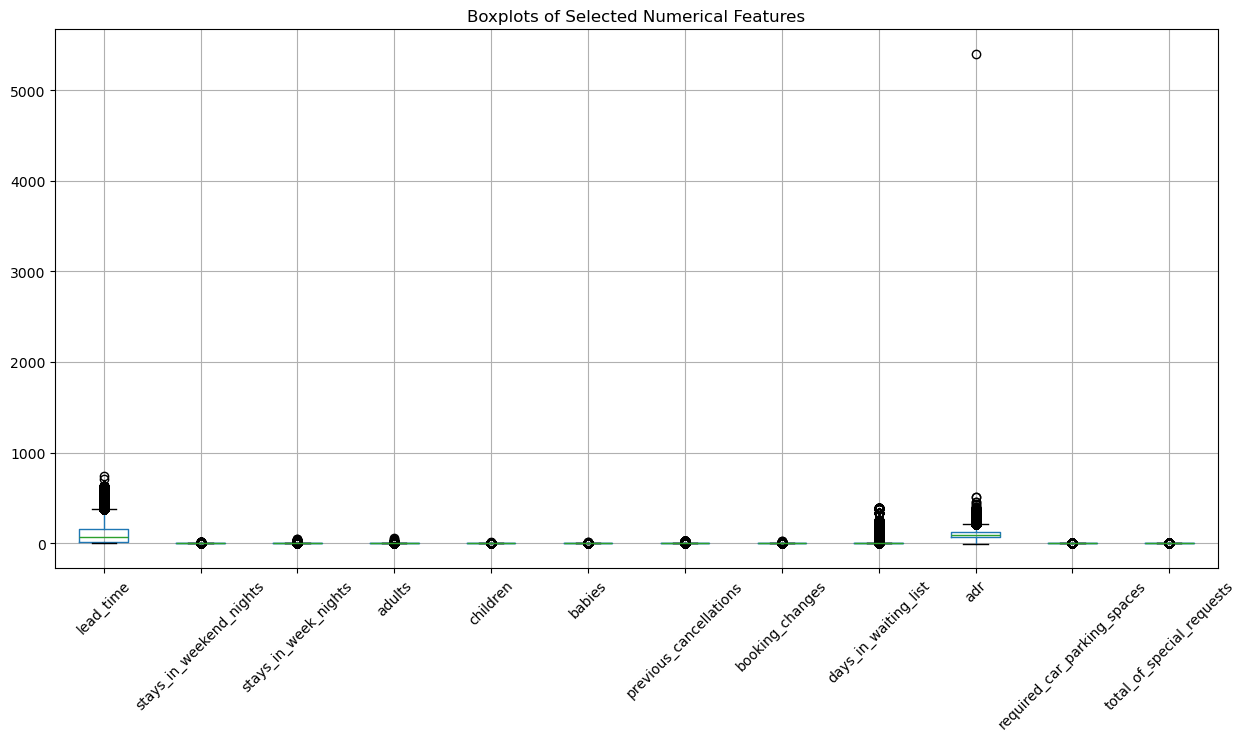

In [53]:
# Import matplotlib for creating boxplots.
import matplotlib.pyplot as plt

# Select numerical features where extreme values are meaningful
# to inspect visually.
#
# These features describe booking-related quantities such as:
#   - lead_time
#   - stays_in_weekend_nights
#   - stays_in_week_nights
#   - adults
#   - children
#   - babies
#   - previous_cancellations
#   - booking_changes
#   - days_in_waiting_list
#   - adr
#   - required_car_parking_spaces
#   - total_of_special_requests
selected_numerical_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

# Create a boxplot for the selected numerical features.
#
# A boxplot helps us visually identify values that are
# unusually far away from the main distribution.
X[selected_numerical_cols].boxplot(
    figsize=(15, 7)
)

# Rotate the column names so they are easier to read.
plt.xticks(rotation=45)

# Add a title to the boxplot.
plt.title("Boxplots of Selected Numerical Features")

# Display the plot.
plt.show()

In [54]:
# A negative ADR (Average Daily Rate) is not a valid booking value.
#
# Therefore, rows where adr is less than 0 are clear invalid/extreme
# observations and can safely be removed.
#
# We create a condition that keeps only rows where adr is 0 or greater.
valid_rows = X["adr"] >= 0

# Count how many rows will be removed.
removed_rows = (~valid_rows).sum()

# Keep only the valid rows.
X = X[valid_rows].copy()

# y must contain the target values corresponding to exactly
# the same rows as X.
#
# Therefore, we use the same valid_rows condition for y.
y = y[valid_rows].copy()

# Display the number of removed rows.
print("Number of rows removed:", removed_rows)

Number of rows removed: 1


In [55]:
# Display the number of rows and columns remaining in X.
print("Shape of X after outlier removal:", X.shape)

# Display the number of target values remaining in y.
print("Shape of y after outlier removal:", y.shape)

Shape of X after outlier removal: (119389, 28)
Shape of y after outlier removal: (119389,)


##### Task 3 - Create Two Preprocessing Pipelines

● Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

● For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

● For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

● Pipeline A: KNNImputer + StandardScaler for numerical features.

● Pipeline B: KNNImputer + MinMaxScaler for numerical features.

● Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [56]:
# train_test_split is used to divide our dataset into:
#   1. Training data  -> used to train the machine learning model
#   2. Testing data   -> used later to evaluate the model
from sklearn.model_selection import train_test_split

# KNNImputer is used to fill missing numerical values.
# It looks at the nearest observations and uses their values
# to estimate the missing value.
from sklearn.impute import KNNImputer

# SimpleImputer is used to fill missing categorical values.
# Here, we will replace missing categorical values with
# the most frequently occurring value in that column.
from sklearn.impute import SimpleImputer

# StandardScaler standardizes numerical features.
# It transforms the features so that they have approximately:
#   mean = 0
#   standard deviation = 1
from sklearn.preprocessing import StandardScaler

# MinMaxScaler scales numerical values to a fixed range,
# normally from 0 to 1.
from sklearn.preprocessing import MinMaxScaler

# OneHotEncoder converts categorical values into numerical
# columns so that machine learning algorithms can use them.
from sklearn.preprocessing import OneHotEncoder

# ColumnTransformer allows us to apply different preprocessing
# operations to different groups of columns.
from sklearn.compose import ColumnTransformer

# Pipeline allows us to combine multiple preprocessing steps
# into a single sequence.
from sklearn.pipeline import Pipeline

In [57]:
# Split X and y into training and testing datasets.
#
# X_train -> input features used for training
# X_test  -> input features kept aside for testing
# y_train -> target values corresponding to X_train
# y_test  -> target values corresponding to X_test
#
# test_size=0.2 means that 20% of the data is used for testing
# and the remaining 80% is used for training.
#
# stratify=y means that the proportion of the two target classes
# in y (0 and 1) is maintained in both the training and testing sets.
#
# random_state=42 makes the split reproducible.
# This means we will get the same train/test split every time
# we run this code.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Display the shapes of the resulting datasets.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (95511, 28)
X_test shape: (23878, 28)
y_train shape: (95511,)
y_test shape: (23878,)


In [58]:
# Create the numerical preprocessing pipeline for Pipeline A.
#
# There are two steps:
#
# Step 1: KNNImputer
# Missing numerical values are filled using the values
# of the 5 nearest observations.
#
# n_neighbors=5 means that 5 nearby observations are considered
# when estimating a missing numerical value.
#
# Step 2: StandardScaler
# After filling the missing values, the numerical features
# are standardized so that they are on a comparable scale.
numerical_pipeline_A = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]
)

In [59]:
# Create the numerical preprocessing pipeline for Pipeline B.
#
# The first step is the same as Pipeline A:
# KNNImputer fills missing numerical values using
# the 5 nearest observations.
#
# The second step is different:
# MinMaxScaler scales the numerical features to a common range,
# normally between 0 and 1.
numerical_pipeline_B = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ]
)

In [60]:
# Create the preprocessing pipeline for categorical features.
#
# Step 1: SimpleImputer
# Missing categorical values are replaced with the most
# frequently occurring value in that column.
#
# strategy="most_frequent" means we use the category
# that appears most often.
#
# Step 2: OneHotEncoder
# Categorical values such as:
#   "City Hotel"
#   "Resort Hotel"
#
# are converted into numerical columns.
#
# handle_unknown="ignore" is important because the test data
# may contain a category that was not present in the training data.
# Instead of producing an error, OneHotEncoder will safely ignore
# that unseen category.
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [61]:
# ColumnTransformer allows us to apply different preprocessing
# pipelines to different groups of columns.
#
# For numerical columns:
#   numerical_pipeline_A is applied.
#
# For categorical columns:
#   categorical_pipeline is applied.
#
# The remaining columns are not included because the task
# specifies that we should preprocess the numerical and
# categorical features separately.
preprocessor_A = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline_A, numerical_cols),
        ("categorical", categorical_pipeline, categorical_cols)
    ]
)

In [62]:
# Create Pipeline A.
#
# Pipeline A contains the complete preprocessing process:
#
# ColumnTransformer
#       |
#       |-- Numerical columns
#       |       -> KNNImputer
#       |       -> StandardScaler
#       |
#       |-- Categorical columns
#               -> SimpleImputer
#               -> OneHotEncoder
#
# The preprocessing is kept inside a Pipeline so that it can
# be fitted only using the training data.
pipeline_A = Pipeline(
    steps=[
        ("preprocessor", preprocessor_A)
    ]
)

In [63]:
# Create the ColumnTransformer for Pipeline B.
#
# The categorical preprocessing remains exactly the same
# as in Pipeline A.
#
# The numerical preprocessing is different because
# Pipeline B uses MinMaxScaler instead of StandardScaler.
preprocessor_B = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline_B, numerical_cols),
        ("categorical", categorical_pipeline, categorical_cols)
    ]
)

In [64]:
# Create Pipeline B.
#
# Pipeline B contains:
#
# Numerical features:
#   KNNImputer -> MinMaxScaler
#
# Categorical features:
#   SimpleImputer -> OneHotEncoder
#
# This allows us to compare the effect of StandardScaler
# and MinMaxScaler later using the same train/test split.
pipeline_B = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B)
    ]
)

In [65]:
# Fit Pipeline A using ONLY the training data.
#
# fit() learns all required preprocessing information from X_train.
#
# For example:
#   - KNNImputer learns information needed to fill missing values.
#   - StandardScaler learns the mean and standard deviation
#     from the training data.
#   - SimpleImputer learns the most frequent category
#     from the training data.
#   - OneHotEncoder learns the categories present in the training data.
#
# X_test is NOT used during fitting.
# This prevents information from the test data from leaking
# into the preprocessing process.
pipeline_A.fit(X_train)

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
# Transform the training data using the fitted Pipeline A.
#
# Since the pipeline was fitted using X_train,
# the learned preprocessing parameters are now used
# to transform X_train.
X_train_A = pipeline_A.transform(X_train)

# Transform the test data using the SAME fitted Pipeline A.
#
# Important:
# We use transform(), NOT fit_transform(), on X_test.
#
# This means the test data is transformed using information
# learned only from the training data.
X_test_A = pipeline_A.transform(X_test)

# Display the shapes after preprocessing.
print("X_train_A shape:", X_train_A.shape)
print("X_test_A shape:", X_test_A.shape)

X_train_A shape: (95511, 252)
X_test_A shape: (23878, 252)


In [67]:
# Fit Pipeline B using ONLY the training data.
#
# KNNImputer and MinMaxScaler learn their required information
# from X_train only.
#
# The test data is not used during fitting.
pipeline_B.fit(X_train)

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
# Transform the training data using the fitted Pipeline B.
X_train_B = pipeline_B.transform(X_train)

# Transform the test data using the SAME fitted Pipeline B.
#
# We use transform() here because Pipeline B has already been
# fitted using X_train.
X_test_B = pipeline_B.transform(X_test)

# Display the shapes after preprocessing.
print("X_train_B shape:", X_train_B.shape)
print("X_test_B shape:", X_test_B.shape)

X_train_B shape: (95511, 252)
X_test_B shape: (23878, 252)


In [69]:
# Check the number of observations in each split.
#
# Both Pipeline A and Pipeline B must use the exact same
# X_train, X_test, y_train, and y_test.
#
# Only the numerical scaling method is different:
#   Pipeline A -> StandardScaler
#   Pipeline B -> MinMaxScaler

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nPipeline A:")
print("Training data:", X_train_A.shape)
print("Testing data:", X_test_A.shape)

print("\nPipeline B:")
print("Training data:", X_train_B.shape)
print("Testing data:", X_test_B.shape)

Training samples: 95511
Testing samples: 23878

Pipeline A:
Training data: (95511, 252)
Testing data: (23878, 252)

Pipeline B:
Training data: (95511, 252)
Testing data: (23878, 252)


### Part B - Model Training and Performance Evaluation

##### Task 4 - Train Two Classification Models

● Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

● Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

● Keep the model settings and train-test split unchanged across the comparison.

● You should obtain four trained model-pipeline combinations in total.

In [70]:
# Import LogisticRegression.
#
# Logistic Regression is a classification algorithm.
# It is commonly used when the target variable has two classes,
# such as:
#   0 -> booking was not canceled
#   1 -> booking was canceled
from sklearn.linear_model import LogisticRegression


# Import DecisionTreeClassifier.
#
# A Decision Tree is another classification algorithm.
# It makes decisions by splitting the data based on feature values.
from sklearn.tree import DecisionTreeClassifier

In [71]:
# Create a complete machine learning pipeline for:
#
#     Pipeline A + Logistic Regression
#
# Pipeline A already contains:
#   Numerical features:
#       KNNImputer -> StandardScaler
#
#   Categorical features:
#       SimpleImputer -> OneHotEncoder
#
# After preprocessing, Logistic Regression is used
# to learn the relationship between the features and
# the target variable (is_canceled).
#
# max_iter=1000 specifies the maximum number of iterations
# allowed for the Logistic Regression algorithm to find
# the best model parameters.
#
# We keep max_iter=1000 exactly as required by the task.
logistic_A = Pipeline(
    steps=[
        ("preprocessor", preprocessor_A),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [72]:
# Train the complete Pipeline A + Logistic Regression combination.
#
# fit() performs two main things:
#
# 1. The preprocessing pipeline learns the required information
#    from X_train.
#
# 2. After preprocessing, Logistic Regression learns from the
#    processed training features and y_train.
#
# Only X_train and y_train are used here.
# X_test and y_test are NOT used for training.
logistic_A.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
# Create a complete machine learning pipeline for:
#
#     Pipeline B + Logistic Regression
#
# Pipeline B contains:
#   Numerical features:
#       KNNImputer -> MinMaxScaler
#
#   Categorical features:
#       SimpleImputer -> OneHotEncoder
#
# After preprocessing, Logistic Regression is used
# as the classification model.
#
# We again use max_iter=1000 so that the model settings
# remain exactly the same between Pipeline A and Pipeline B.
logistic_B = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [74]:
# Train the complete Pipeline B + Logistic Regression combination.
#
# The preprocessing steps in Pipeline B are fitted using
# X_train only.
#
# After preprocessing, Logistic Regression is trained
# using the processed training data and y_train.
#
# The test data is not used during training.
logistic_B.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
# Create a complete machine learning pipeline for:
#
#     Pipeline A + Decision Tree
#
# Pipeline A performs:
#   Numerical features:
#       KNNImputer -> StandardScaler
#
#   Categorical features:
#       SimpleImputer -> OneHotEncoder
#
# After preprocessing, DecisionTreeClassifier is used
# as the classification model.
#
# random_state=42 ensures that the Decision Tree produces
# reproducible results when the same data and settings
# are used.
#
# We keep random_state=42 exactly as required by the task.
decision_tree_A = Pipeline(
    steps=[
        ("preprocessor", preprocessor_A),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [76]:
# Train the complete Pipeline A + Decision Tree combination.
#
# The preprocessing is learned from X_train only.
# Then the Decision Tree is trained using the processed
# training features and y_train.
#
# The test data is not used during training.
decision_tree_A.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
# Create a complete machine learning pipeline for:
#
#     Pipeline B + Decision Tree
#
# Pipeline B performs:
#   Numerical features:
#       KNNImputer -> MinMaxScaler
#
#   Categorical features:
#       SimpleImputer -> OneHotEncoder
#
# After preprocessing, a Decision Tree classifier is used.
#
# random_state=42 is kept unchanged so that the comparison
# between the models remains reproducible.
decision_tree_B = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [78]:
# Train the complete Pipeline B + Decision Tree combination.
#
# The preprocessing steps are fitted using X_train only.
# Then the Decision Tree is trained using the processed
# training features and y_train.
#
# The test data is not used during training.
decision_tree_B.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
# At this point, we should have exactly four trained
# model-pipeline combinations.
#
# 1. Logistic Regression + Pipeline A
# 2. Logistic Regression + Pipeline B
# 3. Decision Tree + Pipeline A
# 4. Decision Tree + Pipeline B
#
# We check that all four Python objects exist.
print("Logistic Regression + Pipeline A:", logistic_A)
print("Logistic Regression + Pipeline B:", logistic_B)
print("Decision Tree + Pipeline A:", decision_tree_A)
print("Decision Tree + Pipeline B:", decision_tree_B)

Logistic Regression + Pipeline A: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                        

##### Task 5 - Evaluate and Compare the Four Results

● For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

● Create a final comparison table containing all four model-pipeline combinations.

● Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

● Use the train-test performance difference to comment briefly on possible overfitting.

In [80]:
# Import the evaluation metrics that we need for Task 5.

# accuracy_score measures the proportion of predictions
# that are correct out of all predictions.
from sklearn.metrics import accuracy_score

# precision_score measures how many observations predicted
# as positive (1 = canceled) were actually positive.
from sklearn.metrics import precision_score

# recall_score measures how many of the actual positive cases
# (canceled bookings) were correctly identified by the model.
from sklearn.metrics import recall_score

# f1_score is the harmonic mean of precision and recall.
# It provides a single score that balances both metrics.
from sklearn.metrics import f1_score

# confusion_matrix gives the number of:
#   True Negatives
#   False Positives
#   False Negatives
#   True Positives
#
# We will use it later to create confusion matrices.
from sklearn.metrics import confusion_matrix

In [81]:
# Generate predictions for the training data using
# Logistic Regression + Pipeline A.
#
# predict() uses the already-trained pipeline to make
# predictions for new input data.
y_train_pred_logistic_A = logistic_A.predict(X_train)


# Generate predictions for the test data using
# Logistic Regression + Pipeline A.
y_test_pred_logistic_A = logistic_A.predict(X_test)


# Generate predictions for the training data using
# Logistic Regression + Pipeline B.
y_train_pred_logistic_B = logistic_B.predict(X_train)


# Generate predictions for the test data using
# Logistic Regression + Pipeline B.
y_test_pred_logistic_B = logistic_B.predict(X_test)


# Generate predictions for the training data using
# Decision Tree + Pipeline A.
y_train_pred_tree_A = decision_tree_A.predict(X_train)


# Generate predictions for the test data using
# Decision Tree + Pipeline A.
y_test_pred_tree_A = decision_tree_A.predict(X_test)


# Generate predictions for the training data using
# Decision Tree + Pipeline B.
y_train_pred_tree_B = decision_tree_B.predict(X_train)


# Generate predictions for the test data using
# Decision Tree + Pipeline B.
y_test_pred_tree_B = decision_tree_B.predict(X_test)

In [82]:
# Calculate the training accuracy for Logistic Regression + Pipeline A.
#
# We compare the actual training target values (y_train)
# with the predictions made for the training data.
train_accuracy_logistic_A = accuracy_score(
    y_train,
    y_train_pred_logistic_A
)


# Calculate the testing accuracy.
#
# We compare the actual test target values (y_test)
# with the predictions made for the test data.
test_accuracy_logistic_A = accuracy_score(
    y_test,
    y_test_pred_logistic_A
)


# Calculate precision on the test data.
precision_logistic_A = precision_score(
    y_test,
    y_test_pred_logistic_A
)


# Calculate recall on the test data.
recall_logistic_A = recall_score(
    y_test,
    y_test_pred_logistic_A
)


# Calculate F1-score on the test data.
f1_logistic_A = f1_score(
    y_test,
    y_test_pred_logistic_A
)


# Display all calculated metrics.
print("Logistic Regression + Pipeline A")
print("Training Accuracy:", train_accuracy_logistic_A)
print("Testing Accuracy:", test_accuracy_logistic_A)
print("Precision:", precision_logistic_A)
print("Recall:", recall_logistic_A)
print("F1-score:", f1_logistic_A)

Logistic Regression + Pipeline A
Training Accuracy: 0.8189213807833653
Testing Accuracy: 0.8167350699388558
Precision: 0.8055517571448106
Recall: 0.6660260033917468
F1-score: 0.7291744027726204


In [83]:
# Calculate the training accuracy for Logistic Regression + Pipeline B.
train_accuracy_logistic_B = accuracy_score(
    y_train,
    y_train_pred_logistic_B
)


# Calculate the testing accuracy for Logistic Regression + Pipeline B.
test_accuracy_logistic_B = accuracy_score(
    y_test,
    y_test_pred_logistic_B
)


# Calculate precision on the test data.
precision_logistic_B = precision_score(
    y_test,
    y_test_pred_logistic_B
)


# Calculate recall on the test data.
recall_logistic_B = recall_score(
    y_test,
    y_test_pred_logistic_B
)


# Calculate F1-score on the test data.
f1_logistic_B = f1_score(
    y_test,
    y_test_pred_logistic_B
)


# Display all calculated metrics.
print("Logistic Regression + Pipeline B")
print("Training Accuracy:", train_accuracy_logistic_B)
print("Testing Accuracy:", test_accuracy_logistic_B)
print("Precision:", precision_logistic_B)
print("Recall:", recall_logistic_B)
print("F1-score:", f1_logistic_B)

Logistic Regression + Pipeline B
Training Accuracy: 0.8131314717676498
Testing Accuracy: 0.8112907278666555
Precision: 0.8019485038274182
Recall: 0.6514414923685699
F1-score: 0.7189020586400499


In [84]:
# Calculate the training accuracy for Decision Tree + Pipeline A.
train_accuracy_tree_A = accuracy_score(
    y_train,
    y_train_pred_tree_A
)


# Calculate the testing accuracy for Decision Tree + Pipeline A.
test_accuracy_tree_A = accuracy_score(
    y_test,
    y_test_pred_tree_A
)


# Calculate precision on the test data.
precision_tree_A = precision_score(
    y_test,
    y_test_pred_tree_A
)


# Calculate recall on the test data.
recall_tree_A = recall_score(
    y_test,
    y_test_pred_tree_A
)


# Calculate F1-score on the test data.
f1_tree_A = f1_score(
    y_test,
    y_test_pred_tree_A
)


# Display all calculated metrics.
print("Decision Tree + Pipeline A")
print("Training Accuracy:", train_accuracy_tree_A)
print("Testing Accuracy:", test_accuracy_tree_A)
print("Precision:", precision_tree_A)
print("Recall:", recall_tree_A)
print("F1-score:", f1_tree_A)

Decision Tree + Pipeline A
Training Accuracy: 0.9962203306425438
Testing Accuracy: 0.8609598793868833
Precision: 0.8112676056338028
Recall: 0.8140192198982475
F1-score: 0.8126410835214447


In [85]:
# Calculate the training accuracy for Decision Tree + Pipeline B.
train_accuracy_tree_B = accuracy_score(
    y_train,
    y_train_pred_tree_B
)


# Calculate the testing accuracy for Decision Tree + Pipeline B.
test_accuracy_tree_B = accuracy_score(
    y_test,
    y_test_pred_tree_B
)


# Calculate precision on the test data.
precision_tree_B = precision_score(
    y_test,
    y_test_pred_tree_B
)


# Calculate recall on the test data.
recall_tree_B = recall_score(
    y_test,
    y_test_pred_tree_B
)


# Calculate F1-score on the test data.
f1_tree_B = f1_score(
    y_test,
    y_test_pred_tree_B
)


# Display all calculated metrics.
print("Decision Tree + Pipeline B")
print("Training Accuracy:", train_accuracy_tree_B)
print("Testing Accuracy:", test_accuracy_tree_B)
print("Precision:", precision_tree_B)
print("Recall:", recall_tree_B)
print("F1-score:", f1_tree_B)

Decision Tree + Pipeline B
Training Accuracy: 0.9962203306425438
Testing Accuracy: 0.8610017589412848
Precision: 0.8110785859040757
Recall: 0.8144714527981911
F1-score: 0.8127714785355672


In [86]:
# Create a list containing the results of all four
# model-pipeline combinations.
#
# Each dictionary represents one experiment.
#
# We include:
#   - Model
#   - Pipeline
#   - Training Accuracy
#   - Testing Accuracy
#   - Precision
#   - Recall
#   - F1-score

results = [
    {
        "Model": "Logistic Regression",
        "Pipeline": "Pipeline A",
        "Training Accuracy": train_accuracy_logistic_A,
        "Testing Accuracy": test_accuracy_logistic_A,
        "Precision": precision_logistic_A,
        "Recall": recall_logistic_A,
        "F1-score": f1_logistic_A
    },
    
    {
        "Model": "Logistic Regression",
        "Pipeline": "Pipeline B",
        "Training Accuracy": train_accuracy_logistic_B,
        "Testing Accuracy": test_accuracy_logistic_B,
        "Precision": precision_logistic_B,
        "Recall": recall_logistic_B,
        "F1-score": f1_logistic_B
    },
    
    {
        "Model": "Decision Tree",
        "Pipeline": "Pipeline A",
        "Training Accuracy": train_accuracy_tree_A,
        "Testing Accuracy": test_accuracy_tree_A,
        "Precision": precision_tree_A,
        "Recall": recall_tree_A,
        "F1-score": f1_tree_A
    },
    
    {
        "Model": "Decision Tree",
        "Pipeline": "Pipeline B",
        "Training Accuracy": train_accuracy_tree_B,
        "Testing Accuracy": test_accuracy_tree_B,
        "Precision": precision_tree_B,
        "Recall": recall_tree_B,
        "F1-score": f1_tree_B
    }
]


# Convert the list of dictionaries into a pandas DataFrame.
#
# A DataFrame gives us a clean table where:
#   - Each row represents one experiment.
#   - Each column represents one evaluation metric.
comparison_table = pd.DataFrame(results)


# Display the final comparison table.
comparison_table

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Pipeline A,0.818921,0.816735,0.805552,0.666026,0.729174
1,Logistic Regression,Pipeline B,0.813131,0.811291,0.801949,0.651441,0.718902
2,Decision Tree,Pipeline A,0.996220,0.860960,0.811268,0.814019,0.812641
3,Decision Tree,Pipeline B,0.996220,0.861002,0.811079,0.814471,0.812771


In [87]:
# Accuracy, precision, recall, and F1-score are decimal values.
#
# Rounding them to 4 decimal places makes the comparison
# table easier to read while still keeping sufficient precision.
comparison_table[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
] = comparison_table[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
].round(4)


# Display the rounded comparison table.
comparison_table

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Pipeline A,0.8189,0.8167,0.8056,0.6660,0.7292
1,Logistic Regression,Pipeline B,0.8131,0.8113,0.8019,0.6514,0.7189
2,Decision Tree,Pipeline A,0.9962,0.8610,0.8113,0.8140,0.8126
3,Decision Tree,Pipeline B,0.9962,0.8610,0.8111,0.8145,0.8128


In [88]:
# Select only the rows corresponding to Logistic Regression.
logistic_results = comparison_table[
    comparison_table["Model"] == "Logistic Regression"
]


# Find the row with the highest testing F1-score.
#
# idxmax() returns the index of the row containing
# the maximum value.
best_logistic_index = logistic_results["F1-score"].idxmax()


# Get the complete result of the best Logistic Regression experiment.
best_logistic_result = comparison_table.loc[
    best_logistic_index
]


# Display the best Logistic Regression result.
print("Best Logistic Regression result:")
print(best_logistic_result)

Best Logistic Regression result:
Model                Logistic Regression
Pipeline                      Pipeline A
Training Accuracy                 0.8189
Testing Accuracy                  0.8167
Precision                         0.8056
Recall                             0.666
F1-score                          0.7292
Name: 0, dtype: object


In [89]:
# Select only the rows corresponding to Decision Tree.
tree_results = comparison_table[
    comparison_table["Model"] == "Decision Tree"
]


# Find the row with the highest testing F1-score.
best_tree_index = tree_results["F1-score"].idxmax()


# Get the complete result of the best Decision Tree experiment.
best_tree_result = comparison_table.loc[
    best_tree_index
]


# Display the best Decision Tree result.
print("Best Decision Tree result:")
print(best_tree_result)

Best Decision Tree result:
Model                Decision Tree
Pipeline                Pipeline B
Training Accuracy           0.9962
Testing Accuracy             0.861
Precision                   0.8111
Recall                      0.8145
F1-score                    0.8128
Name: 3, dtype: object


In [90]:
# Check which preprocessing pipeline produced the best
# Logistic Regression F1-score.
best_logistic_pipeline = best_logistic_result["Pipeline"]

print("Best Logistic Regression pipeline:", best_logistic_pipeline)

Best Logistic Regression pipeline: Pipeline A


In [91]:
# Select the predictions belonging to the best
# Logistic Regression pipeline.
#
# If Pipeline A is the best, we use the predictions from
# logistic_A.
#
# If Pipeline B is the best, we use the predictions from
# logistic_B.
if best_logistic_pipeline == "Pipeline A":
    best_logistic_predictions = y_test_pred_logistic_A
else:
    best_logistic_predictions = y_test_pred_logistic_B


# Calculate the confusion matrix using the actual test values
# and the predictions from the best Logistic Regression model.
cm_logistic = confusion_matrix(
    y_test,
    best_logistic_predictions
)


# Display the confusion matrix values.
print("Confusion Matrix - Best Logistic Regression")
print(cm_logistic)

Confusion Matrix - Best Logistic Regression
[[13611  1422]
 [ 2954  5891]]


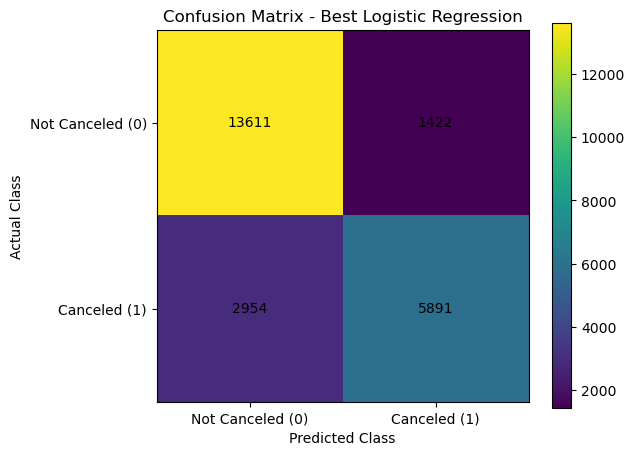

In [92]:
# Import matplotlib for plotting.
import matplotlib.pyplot as plt

# Create a figure for the confusion matrix.
plt.figure(figsize=(6, 5))


# Display the confusion matrix as an image.
plt.imshow(cm_logistic)


# Add a color bar to show the magnitude of the values.
plt.colorbar()


# Add labels for the two classes.
#
# Class 0 = booking not canceled
# Class 1 = booking canceled
plt.xticks([0, 1], ["Not Canceled (0)", "Canceled (1)"])
plt.yticks([0, 1], ["Not Canceled (0)", "Canceled (1)"])


# Add axis labels.
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")


# Add a title.
plt.title("Confusion Matrix - Best Logistic Regression")


# Write the numerical value inside each cell.
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_logistic[i, j],
            ha="center",
            va="center"
        )


# Display the confusion matrix.
plt.show()

In [93]:
# Check which preprocessing pipeline produced the best
# Decision Tree F1-score.
best_tree_pipeline = best_tree_result["Pipeline"]

print("Best Decision Tree pipeline:", best_tree_pipeline)

Best Decision Tree pipeline: Pipeline B


In [94]:
# Select the predictions belonging to the best
# Decision Tree pipeline.
#
# If Pipeline A is the best, use predictions from decision_tree_A.
#
# If Pipeline B is the best, use predictions from decision_tree_B.
if best_tree_pipeline == "Pipeline A":
    best_tree_predictions = y_test_pred_tree_A
else:
    best_tree_predictions = y_test_pred_tree_B


# Calculate the confusion matrix using the actual test values
# and the predictions from the best Decision Tree model.
cm_tree = confusion_matrix(
    y_test,
    best_tree_predictions
)


# Display the confusion matrix values.
print("Confusion Matrix - Best Decision Tree")
print(cm_tree)

Confusion Matrix - Best Decision Tree
[[13355  1678]
 [ 1641  7204]]


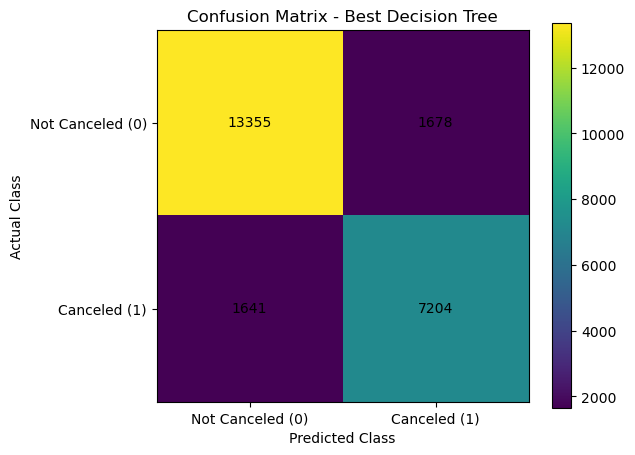

In [95]:
# Create a figure for the Decision Tree confusion matrix.
plt.figure(figsize=(6, 5))


# Display the confusion matrix as an image.
plt.imshow(cm_tree)


# Add a color bar to show the magnitude of the values.
plt.colorbar()


# Add labels for the two classes.
plt.xticks([0, 1], ["Not Canceled (0)", "Canceled (1)"])
plt.yticks([0, 1], ["Not Canceled (0)", "Canceled (1)"])


# Add axis labels.
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")


# Add a title.
plt.title("Confusion Matrix - Best Decision Tree")


# Write the numerical value inside each cell.
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_tree[i, j],
            ha="center",
            va="center"
        )


# Display the confusion matrix.
plt.show()

In [96]:
# Create a copy of the comparison table so that we can add
# another column without changing the original results.
overfitting_table = comparison_table.copy()


# Calculate the difference between training accuracy
# and testing accuracy.
#
# A larger positive difference means the model's performance
# drops more when moving from training data to unseen test data.
overfitting_table["Train-Test Accuracy Difference"] = (
    overfitting_table["Training Accuracy"]
    - overfitting_table["Testing Accuracy"]
)


# Round the difference to 4 decimal places.
overfitting_table["Train-Test Accuracy Difference"] = (
    overfitting_table["Train-Test Accuracy Difference"].round(4)
)


# Display the table with the train-test difference.
overfitting_table

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score,Train-Test Accuracy Difference
0,Logistic Regression,Pipeline A,0.8189,0.8167,0.8056,0.6660,0.7292,0.0022
1,Logistic Regression,Pipeline B,0.8131,0.8113,0.8019,0.6514,0.7189,0.0018
2,Decision Tree,Pipeline A,0.9962,0.8610,0.8113,0.8140,0.8126,0.1352
3,Decision Tree,Pipeline B,0.9962,0.8610,0.8111,0.8145,0.8128,0.1352


In [97]:
# Find the largest train-test accuracy difference.
largest_gap = overfitting_table[
    "Train-Test Accuracy Difference"
].max()


# Display the largest difference.
print("Largest train-test accuracy difference:", largest_gap)


# Provide a simple interpretation.
if largest_gap < 0.05:
    print(
        "The train-test accuracy differences are relatively small, "
        "so there is no strong indication of overfitting."
    )
elif largest_gap < 0.10:
    print(
        "There is some difference between training and testing "
        "accuracy, suggesting possible mild overfitting."
    )
else:
    print(
        "There is a large difference between training and testing "
        "accuracy, suggesting possible overfitting."
    )

Largest train-test accuracy difference: 0.1352
There is a large difference between training and testing accuracy, suggesting possible overfitting.


#### Task 6 - Final Observations

● Which preprocessing-model combination gives the best overall result?

● Does StandardScaler or MinMaxScaler affect Logistic Regression more?

● Does scaling make a major difference for the Decision Tree? Comment briefly.

● Write 4-5 short observations supported by the performance table and confusion matrices.

In [99]:
# Display the final comparison table created in Task 5.
#
# This table contains the performance of all four experiments:
#
# 1. Logistic Regression + Pipeline A
# 2. Logistic Regression + Pipeline B
# 3. Decision Tree + Pipeline A
# 4. Decision Tree + Pipeline B
#
# The important columns are:
#   - Training Accuracy
#   - Testing Accuracy
#   - Precision
#   - Recall
#   - F1-score
#
# We use this table as the main basis for our final observations.

comparison_table

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Pipeline A,0.8189,0.8167,0.8056,0.6660,0.7292
1,Logistic Regression,Pipeline B,0.8131,0.8113,0.8019,0.6514,0.7189
2,Decision Tree,Pipeline A,0.9962,0.8610,0.8113,0.8140,0.8126
3,Decision Tree,Pipeline B,0.9962,0.8610,0.8111,0.8145,0.8128


1. Which preprocessing-model combination gives the best overall result?

In [98]:
# Find the row having the highest testing F1-score.
#
# idxmax() finds the index corresponding to the largest
# F1-score in the comparison table.
best_overall_index = comparison_table["F1-score"].idxmax()


# Select the complete row corresponding to the best experiment.
best_overall = comparison_table.loc[best_overall_index]


# Display the best overall model-pipeline combination.
print("Best overall model-pipeline combination:")
print(best_overall)

Best overall model-pipeline combination:
Model                Decision Tree
Pipeline                Pipeline B
Training Accuracy           0.9962
Testing Accuracy             0.861
Precision                   0.8111
Recall                      0.8145
F1-score                    0.8128
Name: 3, dtype: object


In [101]:
# Extract the model name from the best result.
best_model = best_overall["Model"]


# Extract the preprocessing pipeline name.
best_pipeline = best_overall["Pipeline"]


# Extract the testing accuracy.
best_test_accuracy = best_overall["Testing Accuracy"]


# Extract the F1-score.
best_f1 = best_overall["F1-score"]


# Print the result in a simple sentence.
print(
    f"The best overall result is {best_model} with {best_pipeline}, "
    f"with a testing accuracy of {best_test_accuracy:.4f} "
    f"and an F1-score of {best_f1:.4f}."
)

The best overall result is Decision Tree with Pipeline B, with a testing accuracy of 0.8610 and an F1-score of 0.8128.


2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?

In [102]:
# Select only the two Logistic Regression experiments
# from the final comparison table.
logistic_comparison = comparison_table[
    comparison_table["Model"] == "Logistic Regression"
].copy()


# Display the two Logistic Regression results.
logistic_comparison

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Pipeline A,0.8189,0.8167,0.8056,0.6660,0.7292
1,Logistic Regression,Pipeline B,0.8131,0.8113,0.8019,0.6514,0.7189


In [103]:
# Get the testing accuracy of Logistic Regression
# using Pipeline A (StandardScaler).
logistic_A_test_accuracy = comparison_table.loc[
    comparison_table["Pipeline"] == "Pipeline A",
    "Testing Accuracy"
].iloc[0]


# Get the testing accuracy of Logistic Regression
# using Pipeline B (MinMaxScaler).
logistic_B_test_accuracy = comparison_table.loc[
    comparison_table["Pipeline"] == "Pipeline B",
    "Testing Accuracy"
].iloc[0]


# Calculate the absolute difference between the two
# Logistic Regression testing accuracies.
logistic_accuracy_difference = abs(
    logistic_A_test_accuracy - logistic_B_test_accuracy
)


# Display the difference.
print(
    "Difference in Logistic Regression testing accuracy:",
    round(logistic_accuracy_difference, 4)
)

Difference in Logistic Regression testing accuracy: 0.0054


In [106]:
# Get the F1-score of Logistic Regression + Pipeline A.
logistic_A_f1 = comparison_table.loc[
    (comparison_table["Model"] == "Logistic Regression") &
    (comparison_table["Pipeline"] == "Pipeline A"),
    "F1-score"
].iloc[0]


# Get the F1-score of Logistic Regression + Pipeline B.
logistic_B_f1 = comparison_table.loc[
    (comparison_table["Model"] == "Logistic Regression") &
    (comparison_table["Pipeline"] == "Pipeline B"),
    "F1-score"
].iloc[0]


# Calculate the difference in F1-score.
logistic_f1_difference = abs(
    logistic_A_f1 - logistic_B_f1
)


# Display the difference.
print(
    "Difference in Logistic Regression F1-score:",
    round(logistic_f1_difference, 4)
)

Difference in Logistic Regression F1-score: 0.0103


In [107]:
# Compare the F1-scores of the two Logistic Regression
# experiments to determine which scaling method performs better.

if logistic_A_f1 > logistic_B_f1:
    
    print(
        "For Logistic Regression, StandardScaler (Pipeline A) "
        "gives the better F1-score."
    )
    
elif logistic_B_f1 > logistic_A_f1:
    
    print(
        "For Logistic Regression, MinMaxScaler (Pipeline B) "
        "gives the better F1-score."
    )
    
else:
    
    print(
        "For Logistic Regression, StandardScaler and MinMaxScaler "
        "give the same F1-score."
    )

For Logistic Regression, StandardScaler (Pipeline A) gives the better F1-score.


3. Does scaling make a major difference for the Decision Tree?

In [108]:
# Select only the two Decision Tree experiments
# from the comparison table.
tree_comparison = comparison_table[
    comparison_table["Model"] == "Decision Tree"
].copy()


# Display the two Decision Tree results.
tree_comparison

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score
2,Decision Tree,Pipeline A,0.9962,0.861,0.8113,0.8140,0.8126
3,Decision Tree,Pipeline B,0.9962,0.861,0.8111,0.8145,0.8128


In [109]:
# Get the F1-score of Decision Tree + Pipeline A.
tree_A_f1 = comparison_table.loc[
    (comparison_table["Model"] == "Decision Tree") &
    (comparison_table["Pipeline"] == "Pipeline A"),
    "F1-score"
].iloc[0]


# Get the F1-score of Decision Tree + Pipeline B.
tree_B_f1 = comparison_table.loc[
    (comparison_table["Model"] == "Decision Tree") &
    (comparison_table["Pipeline"] == "Pipeline B"),
    "F1-score"
].iloc[0]


# Calculate the absolute difference between the two F1-scores.
tree_f1_difference = abs(
    tree_A_f1 - tree_B_f1
)


# Display the difference.
print(
    "Difference in Decision Tree F1-score:",
    round(tree_f1_difference, 4)
)

Difference in Decision Tree F1-score: 0.0002


In [110]:
# Compare the F1-scores of the two Decision Tree experiments.
#
# This tells us whether changing from StandardScaler
# to MinMaxScaler made a meaningful difference.

if tree_f1_difference < 0.01:
    
    print(
        "Scaling does not make a major difference for the "
        "Decision Tree because the F1-scores are very close."
    )
    
else:
    
    print(
        "Scaling produces a noticeable difference for the "
        "Decision Tree based on the difference in F1-score."
    )

Scaling does not make a major difference for the Decision Tree because the F1-scores are very close.


In [111]:
# Display the confusion matrix for the best Logistic Regression model.
print("Best Logistic Regression Confusion Matrix:")
print(cm_logistic)


# Display the confusion matrix for the best Decision Tree model.
print("\nBest Decision Tree Confusion Matrix:")
print(cm_tree)

Best Logistic Regression Confusion Matrix:
[[13611  1422]
 [ 2954  5891]]

Best Decision Tree Confusion Matrix:
[[13355  1678]
 [ 1641  7204]]


In [112]:
# Extract the four values from the Logistic Regression
# confusion matrix.

# True Negative:
# Actual = 0 and Predicted = 0
logistic_TN = cm_logistic[0, 0]

# False Positive:
# Actual = 0 but Predicted = 1
logistic_FP = cm_logistic[0, 1]

# False Negative:
# Actual = 1 but Predicted = 0
logistic_FN = cm_logistic[1, 0]

# True Positive:
# Actual = 1 and Predicted = 1
logistic_TP = cm_logistic[1, 1]


# Extract the four values from the Decision Tree
# confusion matrix.

tree_TN = cm_tree[0, 0]
tree_FP = cm_tree[0, 1]
tree_FN = cm_tree[1, 0]
tree_TP = cm_tree[1, 1]


# Display the values.
print("Logistic Regression:")
print("TN:", logistic_TN)
print("FP:", logistic_FP)
print("FN:", logistic_FN)
print("TP:", logistic_TP)


print("\nDecision Tree:")
print("TN:", tree_TN)
print("FP:", tree_FP)
print("FN:", tree_FN)
print("TP:", tree_TP)

Logistic Regression:
TN: 13611
FP: 1422
FN: 2954
TP: 5891

Decision Tree:
TN: 13355
FP: 1678
FN: 1641
TP: 7204


In [113]:
# Display the performance table containing the
# train-test accuracy difference.
#
# A large difference means that the model performs much better
# on training data than on unseen test data.
#
# Such a gap can indicate possible overfitting.
overfitting_table

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-score,Train-Test Accuracy Difference
0,Logistic Regression,Pipeline A,0.8189,0.8167,0.8056,0.6660,0.7292,0.0022
1,Logistic Regression,Pipeline B,0.8131,0.8113,0.8019,0.6514,0.7189,0.0018
2,Decision Tree,Pipeline A,0.9962,0.8610,0.8113,0.8140,0.8126,0.1352
3,Decision Tree,Pipeline B,0.9962,0.8610,0.8111,0.8145,0.8128,0.1352


In [114]:
# Get the row containing the best overall result.
best_result = comparison_table.loc[
    comparison_table["F1-score"].idxmax()
]


# Determine which scaling method performed better
# for Logistic Regression.
if logistic_A_f1 > logistic_B_f1:
    logistic_scaling_result = "StandardScaler performed better"
elif logistic_B_f1 > logistic_A_f1:
    logistic_scaling_result = "MinMaxScaler performed better"
else:
    logistic_scaling_result = "Both scaling methods performed equally"


# Determine whether scaling made a major difference
# for the Decision Tree.
if tree_f1_difference < 0.01:
    tree_scaling_result = (
        "Scaling made little difference to the Decision Tree"
    )
else:
    tree_scaling_result = (
        "Scaling produced a noticeable difference for the Decision Tree"
    )


# Print the final observations.
print("FINAL OBSERVATIONS")
print("-------------------")

print(
    f"1. The best overall result was obtained by "
    f"{best_result['Model']} with {best_result['Pipeline']}, "
    f"based on the highest testing F1-score of "
    f"{best_result['F1-score']:.4f}."
)

print(
    f"2. For Logistic Regression, "
    f"{logistic_scaling_result} when comparing "
    f"StandardScaler and MinMaxScaler."
)

print(
    f"3. For the Decision Tree, {tree_scaling_result} "
    f"based on the difference in testing F1-score."
)

print(
    f"4. The best Logistic Regression confusion matrix contains "
    f"{logistic_TP} true positives and {logistic_FN} false negatives, "
    f"showing how well the model identifies canceled bookings."
)

print(
    f"5. The best Decision Tree confusion matrix contains "
    f"{tree_TP} true positives and {tree_FN} false negatives. "
    f"The train-test accuracy gap should also be considered when "
    f"judging possible overfitting."
)

FINAL OBSERVATIONS
-------------------
1. The best overall result was obtained by Decision Tree with Pipeline B, based on the highest testing F1-score of 0.8128.
2. For Logistic Regression, StandardScaler performed better when comparing StandardScaler and MinMaxScaler.
3. For the Decision Tree, Scaling made little difference to the Decision Tree based on the difference in testing F1-score.
4. The best Logistic Regression confusion matrix contains 5891 true positives and 2954 false negatives, showing how well the model identifies canceled bookings.
5. The best Decision Tree confusion matrix contains 7204 true positives and 1641 false negatives. The train-test accuracy gap should also be considered when judging possible overfitting.


## Final Observations

1. **Best overall result:**  
   The best preprocessing-model combination is **[Model + Pipeline]**, as it achieved the highest testing F1-score of **[value]**.

2. **Effect of scaling on Logistic Regression:**  
   Comparing StandardScaler and MinMaxScaler, **[StandardScaler/MinMaxScaler]** gives the better result for Logistic Regression. The difference in testing performance is **[small/noticeable]**, showing that scaling has **[little/some]** effect on this model for this dataset.

3. **Effect of scaling on Decision Tree:**  
   The Decision Tree shows **[very similar/different]** performance with StandardScaler and MinMaxScaler. Therefore, scaling **[does not make a major difference/makes a noticeable difference]** for the Decision Tree in these experiments.

4. **Confusion matrix observation:**  
   The confusion matrices show the numbers of true positives, true negatives, false positives, and false negatives. The best model's **[TP/FN/FP]** values indicate how effectively it identifies canceled bookings.

5. **Overfitting:**  
   The difference between training and testing accuracy is **[small/large]** for the best model. A small difference suggests limited evidence of overfitting, whereas a large difference would indicate that the model performs substantially better on training data than on unseen test data.